In [ ]:
# FAZA 7 — Test evaluacija: finalno poređenje sva tri pristupa
#
# Test skup (dani 17-59, 160865 redova, 35 pozitivnih) se koristi prvi
# i jedini put u celom projektu. Sve odluke (izbor modela, skupa atributa,
# hiperparametara, praga) su donete isključivo na train/val.
# Poredim pobedike svake faze:
# Faza 4: RandomForest (Filter, bez balansiranja)
# Faza 5: Transformer (Final, sekvenca)
# Faza 6: Isolation Forest (Filter)

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import RobustScaler

PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
RESULTS = Path(__file__).resolve().parent.parent / "results"
MODELS = Path(__file__).resolve().parent.parent / "models"

SEED = 7
np.random.seed(SEED)

In [ ]:
# --- 1. Učitavanje podataka (isti izvor kao sve prethodne faze) ---
vremenski_prozori = pd.read_parquet(PROC / "features.parquet")

with open(PROC / "imputation_values.json", encoding="utf-8") as f:
    imputation_values = json.load(f)

vremenski_prozori["has_history"] = (vremenski_prozori["window_seq_num"] >= 1).astype(
    int
)
for kolona, vrednost in imputation_values.items():
    if kolona in vremenski_prozori.columns:
        vremenski_prozori[kolona] = vremenski_prozori[kolona].fillna(vrednost)

test = vremenski_prozori[vremenski_prozori["split"] == "test"].reset_index(drop=True)
y_test = test["is_attack"]

print(
    f"test: {len(test)} redova, {int(y_test.sum())} pozitivnih ({y_test.mean() * 100:.3f}%)"
)

test: 160865 redova, 35 pozitivnih (0.022%)


In [ ]:
# --- 2. Učitavanje konfiguracija sva tri pobednika ---
with open(MODELS / "faza4_konfiguracija.json", encoding="utf-8") as f:
    konfig_4 = json.load(f)
with open(MODELS / "faza5_konfiguracija.json", encoding="utf-8") as f:
    konfig_5 = json.load(f)
with open(MODELS / "faza6_konfiguracija.json", encoding="utf-8") as f:
    konfig_6 = json.load(f)

print(
    "Faza 4:",
    konfig_4["model"],
    "-",
    konfig_4["skup_atributa"],
    "- prag:",
    konfig_4["prag"],
)
print(
    "Faza 5:",
    konfig_5["model"],
    "-",
    "seq_len =",
    konfig_5["seq_len"],
    "- prag:",
    konfig_5["prag"],
)
print(
    "Faza 6:",
    konfig_6["model"],
    "-",
    konfig_6["skup_atributa"],
    "- prag:",
    konfig_6["prag"],
)

Faza 4: RandomForest - Filter (40) - prag: 0.16
Faza 5: Transformer - seq_len = 10 - prag: 0.9547625780105591
Faza 6: Isolation Forest - Filter (40) - prag: 0.5376021351868745


In [ ]:
# --- 3. Funkcije za bootstrap interval poverenja i normalizovan AP ---
# Test ima samo 35 pozitivnih primera. To je premalo da bi jedan izračunat
# AP bio pouzdan. Da su ti isti napadi bili raspoređeni malo drugačije npr.
# drugi dani, drugi korisnici, izračunati AP bi mogao ispasti znatno
# drugačiji. Bootstrap simulira tu neizvesnost. Iz test skupa se hiljadu puta
# izvlači nasumičan uzorak, sa vraćanjem, iste veličine kao originalni skup.
# Za svaki uzorak se izračuna AP. Na kraju se prikazuje opseg u kom se AP
# kreće u 95% slučajeva, umesto jednog, lažno preciznog broja.
def bootstrap_ap_ci(y_true, scores, n_iter=1000, ci=0.95, seed=SEED):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    n = len(y_true)
    ap_uzorci = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        y_uzorak = y_true[idx]
        if y_uzorak.sum() == 0 or y_uzorak.sum() == n:
            continue  # bootstrap uzorak sadrži samo jednu klasu, AP tu nije definisan
        ap_uzorci.append(average_precision_score(y_uzorak, scores[idx]))
    donja = np.percentile(ap_uzorci, (1 - ci) / 2 * 100)
    gornja = np.percentile(ap_uzorci, (1 + ci) / 2 * 100)
    return float(donja), float(gornja), len(ap_uzorci)


def normalizovan_ap(ap, y_true):
    udeo_pozitivnih = np.mean(y_true)
    return ap / udeo_pozitivnih if udeo_pozitivnih > 0 else float("nan")

In [ ]:
# --- 4. Faza 4: RandomForest ---
# Filter skup, bez balansiranja.
model_4 = joblib.load(MODELS / "faza4_najbolji_model.pkl")
kolone_4 = konfig_4["kolone"]

X_test_4 = test[kolone_4]
p_test_4 = model_4.predict_proba(X_test_4)[:, 1]

ap_4 = average_precision_score(y_test, p_test_4)
auc_4 = roc_auc_score(y_test, p_test_4)
ci_donja_4, ci_gornja_4, n_validnih_4 = bootstrap_ap_ci(y_test, p_test_4)
nap_4 = normalizovan_ap(ap_4, y_test)

print(
    f"Faza 4 (RandomForest): AP = {ap_4:.4f} [{ci_donja_4:.4f}, {ci_gornja_4:.4f}] "
    f"({n_validnih_4}/1000 validnih uzoraka), AUC-ROC = {auc_4:.4f}, AP normalizovan = {nap_4:.2f}"
)

Faza 4 (RandomForest): AP = 0.0286 [0.0049, 0.1195] (1000/1000 validnih uzoraka), AUC-ROC = 0.9431, AP normalizovan = 131.63


In [ ]:
# --- 5. Faza 5: Transformer ---
# Klasa mora biti identična onoj iz 05_deep_models.py, inače
# load_state_dict() ne može ispravno da učita naučene težine. Dimenzije
# slojeva se moraju tačno poklapati.
class TransformerKlasifikator(nn.Module):
    def __init__(
        self, n_atributa, seq_len, d_model=32, n_head=2, n_slojeva=2, dropout=0.2
    ):
        super().__init__()
        self.projekcija = nn.Linear(n_atributa, d_model)
        self.pozicije = nn.Embedding(seq_len, d_model)
        sloj = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True,
        )
        self.enkoder = nn.TransformerEncoder(sloj, num_layers=n_slojeva)
        self.izlaz = nn.Linear(d_model, 1)

    def forward(self, x):
        batch, koraci, _ = x.shape
        pozicije_idx = (
            torch.arange(koraci, device=x.device).unsqueeze(0).expand(batch, -1)
        )
        x = self.projekcija(x) + self.pozicije(pozicije_idx)
        x = self.enkoder(x)
        poslednji_korak = x[:, -1, :]
        return self.izlaz(poslednji_korak).squeeze(1)


# Sekvence se takođe prave na isti način kao u Fazi 5.
def napravi_sekvence(df, kolone, seq_len):
    """Vraća (df sortiran po entity+window_id, niz oblika (n_redova, seq_len, n_atributa))."""
    df = df.sort_values(["entity", "window_id"]).reset_index(drop=True)
    vrednosti = df[kolone].to_numpy(dtype=np.float32)
    sekvence = np.zeros((len(df), seq_len, len(kolone)), dtype=np.float32)

    for _, grupa in df.groupby("entity", sort=False):
        idx = grupa.index.to_numpy()
        podaci_entiteta = vrednosti[idx]
        for i in range(len(idx)):
            pocetak = max(0, i - seq_len + 1)
            deo_istorije = podaci_entiteta[pocetak : i + 1]
            sekvence[idx[i], seq_len - len(deo_istorije) :, :] = deo_istorije

    return df, sekvence


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kolone_5 = konfig_5["kolone"]
SEQ_LEN = konfig_5["seq_len"]
# Koristimo isti broj slojeva kao u Fazi 5.
BROJ_SLOJEVA = 2

# U Fazi 5 nije sačuvan RobustScaler. Rekreiraću ga ovde na isti
# način. Fitovanje je determinističko za istu kombinaciju kolona
# i trening podele, pa daje identičan rezultat.
skaler_5 = RobustScaler()
trening_maska_5 = vremenski_prozori["split"] == "train"
skaler_5.fit(vremenski_prozori.loc[trening_maska_5, kolone_5])
vremenski_prozori_5 = vremenski_prozori.copy()
vremenski_prozori_5[kolone_5] = skaler_5.transform(vremenski_prozori_5[kolone_5])

vremenski_prozori_5, X_sve_5 = napravi_sekvence(vremenski_prozori_5, kolone_5, SEQ_LEN)
test_maska_5 = (vremenski_prozori_5["split"] == "test").to_numpy()
X_test_5 = X_sve_5[test_maska_5]
y_test_5 = vremenski_prozori_5.loc[test_maska_5, "is_attack"].reset_index(drop=True)

model_5 = TransformerKlasifikator(
    n_atributa=len(kolone_5), seq_len=SEQ_LEN, n_slojeva=BROJ_SLOJEVA
)
model_5.load_state_dict(
    torch.load(MODELS / "faza5_najbolji_model.pt", map_location=DEVICE)
)
model_5.to(DEVICE)
model_5.eval()

with torch.no_grad():
    logiti = model_5(torch.from_numpy(X_test_5).to(DEVICE))
    p_test_5 = torch.sigmoid(logiti).cpu().numpy()

ap_5 = average_precision_score(y_test_5, p_test_5)
auc_5 = roc_auc_score(y_test_5, p_test_5)
ci_donja_5, ci_gornja_5, n_validnih_5 = bootstrap_ap_ci(y_test_5, p_test_5)
nap_5 = normalizovan_ap(ap_5, y_test_5)

print(
    f"Faza 5 (Transformer): AP = {ap_5:.4f} [{ci_donja_5:.4f}, {ci_gornja_5:.4f}] "
    f"({n_validnih_5}/1000 validnih uzoraka), AUC-ROC = {auc_5:.4f}, AP normalizovan = {nap_5:.2f}"
)

# Provera da li je rekonstrukcija skalera i sekvenci ispravna
# Isti rekonstruisani pipeline se primenjuje na validaciju i poredi sa
# sačuvanim ap_validacija iz Faze 5.
val_maska_5 = (vremenski_prozori_5["split"] == "valid").to_numpy()
X_val_5 = X_sve_5[val_maska_5]
y_val_5 = vremenski_prozori_5.loc[val_maska_5, "is_attack"].reset_index(drop=True)

with torch.no_grad():
    logiti_val = model_5(torch.from_numpy(X_val_5).to(DEVICE))
    p_val_5_provera = torch.sigmoid(logiti_val).cpu().numpy()

ap_val_5_provera = average_precision_score(y_val_5, p_val_5_provera)
razlika_ap = abs(ap_val_5_provera - konfig_5["ap_validacija"])

print(
    f"Provera: AP na validaciji sada = {ap_val_5_provera:.4f}, "
    f"u Fazi 5 = {konfig_5['ap_validacija']:.4f}, razlika = {razlika_ap:.5f}"
)
if razlika_ap > 1e-3:
    print("Ne poklapa se sa Fazom 5, proveriti pre nastavka.")
else:
    print("Poklapa se sa Fazom 5.")

Faza 5 (Transformer): AP = 0.0050 [0.0022, 0.0135] (1000/1000 validnih uzoraka), AUC-ROC = 0.8654, AP normalizovan = 22.90
Provera: AP na validaciji sada = 0.0770, u Fazi 5 = 0.0770, razlika = 0.00000
Poklapa se sa Fazom 5.


In [ ]:
# --- 6. Faza 6: Isolation Forest ---
model_6 = joblib.load(MODELS / "faza6_najbolji_model.pkl")
skaler_6 = joblib.load(MODELS / "faza6_skaler.pkl")
kolone_6 = konfig_6["kolone"]

X_test_6 = skaler_6.transform(test[kolone_6])
skor_test_6 = -model_6.score_samples(X_test_6)  # isti obrnut znak kao Faza 6

ap_6 = average_precision_score(y_test, skor_test_6)
auc_6 = roc_auc_score(y_test, skor_test_6)
ci_donja_6, ci_gornja_6, n_validnih_6 = bootstrap_ap_ci(y_test, skor_test_6)
nap_6 = normalizovan_ap(ap_6, y_test)

print(
    f"Faza 6 (Isolation Forest): AP = {ap_6:.4f} [{ci_donja_6:.4f}, {ci_gornja_6:.4f}] "
    f"({n_validnih_6}/1000 validnih uzoraka), AUC-ROC = {auc_6:.4f}, AP normalizovan = {nap_6:.2f}"
)

Faza 6 (Isolation Forest): AP = 0.0020 [0.0010, 0.0046] (1000/1000 validnih uzoraka), AUC-ROC = 0.8813, AP normalizovan = 9.42


In [ ]:
# --- 7. Primena sačuvanih pragova na test skup ---
# Cilj je da se vidi kako se model ponaša u praksi na podacima koje nije video.
# Koriste se već izabrani pragovi iz validacionog skupa u Fazama 4-6.
def primeni_prag(y_true, skor, prag, broj_dana):
    """Vraća (preciznost, odziv, F1, tp, fp, fn, lažne_uzbune_po_danu) za dati prag."""
    y_pred = (skor >= prag).astype(int)
    y_true = np.asarray(y_true)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    preciznost = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    odziv = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * preciznost * odziv / (preciznost + odziv)
        if (preciznost + odziv) > 0
        else 0.0
    )
    return preciznost, odziv, f1, tp, fp, fn, fp / broj_dana


dana_u_testu = test["day"].nunique()

prec_4, odziv_4, f1_4, tp_4, fp_4, fn_4, lazne_dnevno_4 = primeni_prag(
    y_test, p_test_4, konfig_4["prag"], dana_u_testu
)
prec_5, odziv_5, f1_5, tp_5, fp_5, fn_5, lazne_dnevno_5 = primeni_prag(
    y_test_5, p_test_5, konfig_5["prag"], dana_u_testu
)
prec_6, odziv_6, f1_6, tp_6, fp_6, fn_6, lazne_dnevno_6 = primeni_prag(
    y_test, skor_test_6, konfig_6["prag"], dana_u_testu
)

print(
    f"Faza 4 (RandomForest) na pragu {konfig_4['prag']:.6f}: "
    f"preciznost={prec_4:.4f}, odziv={odziv_4:.4f}, F1={f1_4:.4f}, "
    f"uhvaćeno {tp_4}/{tp_4 + fn_4}, lažnih uzbuna {fp_4} ({lazne_dnevno_4:.1f}/dan)"
)
print(
    f"Faza 5 (Transformer) na pragu {konfig_5['prag']:.6f}: "
    f"preciznost={prec_5:.4f}, odziv={odziv_5:.4f}, F1={f1_5:.4f}, "
    f"uhvaćeno {tp_5}/{tp_5 + fn_5}, lažnih uzbuna {fp_5} ({lazne_dnevno_5:.1f}/dan)"
)
print(
    f"Faza 6 (Isolation Forest) na pragu {konfig_6['prag']:.6f}: "
    f"preciznost={prec_6:.4f}, odziv={odziv_6:.4f}, F1={f1_6:.4f}, "
    f"uhvaćeno {tp_6}/{tp_6 + fn_6}, lažnih uzbuna {fp_6} ({lazne_dnevno_6:.1f}/dan)"
)

Faza 4 (RandomForest) na pragu 0.160000: preciznost=0.0177, odziv=0.2857, F1=0.0334, uhvaćeno 10/35, lažnih uzbuna 554 (12.9/dan)
Faza 5 (Transformer) na pragu 0.954763: preciznost=0.0055, odziv=0.3714, F1=0.0108, uhvaćeno 13/35, lažnih uzbuna 2357 (54.8/dan)
Faza 6 (Isolation Forest) na pragu 0.537602: preciznost=0.0022, odziv=0.2000, F1=0.0043, uhvaćeno 7/35, lažnih uzbuna 3188 (74.1/dan)


In [ ]:
# --- 8. Objedinjeni pregled - tabela sa svim rezultatima ---

rezultati_finalni = pd.DataFrame(
    [
        {
            "Faza": "Faza 4",
            "Model": konfig_4["model"],
            "Skup": konfig_4["skup_atributa"],
            "AP test": round(ap_4, 4),
            "AP CI donja": round(ci_donja_4, 4),
            "AP CI gornja": round(ci_gornja_4, 4),
            "AUC-ROC test": round(auc_4, 4),
            "AP normalizovan": round(nap_4, 2),
            "Preciznost": round(prec_4, 4),
            "Odziv": round(odziv_4, 4),
            "F1": round(f1_4, 4),
            "Lažne uzbune/dan": round(lazne_dnevno_4, 1),
            "AP val (Faza 4)": konfig_4["ap_validacija"],
        },
        {
            "Faza": "Faza 5",
            "Model": konfig_5["model"],
            "Skup": "Final (sekvenca)",
            "AP test": round(ap_5, 4),
            "AP CI donja": round(ci_donja_5, 4),
            "AP CI gornja": round(ci_gornja_5, 4),
            "AUC-ROC test": round(auc_5, 4),
            "AP normalizovan": round(nap_5, 2),
            "Preciznost": round(prec_5, 4),
            "Odziv": round(odziv_5, 4),
            "F1": round(f1_5, 4),
            "Lažne uzbune/dan": round(lazne_dnevno_5, 1),
            "AP val (Faza 5)": konfig_5["ap_validacija"],
        },
        {
            "Faza": "Faza 6",
            "Model": konfig_6["model"],
            "Skup": konfig_6["skup_atributa"],
            "AP test": round(ap_6, 4),
            "AP CI donja": round(ci_donja_6, 4),
            "AP CI gornja": round(ci_gornja_6, 4),
            "AUC-ROC test": round(auc_6, 4),
            "AP normalizovan": round(nap_6, 2),
            "Preciznost": round(prec_6, 4),
            "Odziv": round(odziv_6, 4),
            "F1": round(f1_6, 4),
            "Lažne uzbune/dan": round(lazne_dnevno_6, 1),
            "AP val (Faza 6)": konfig_6["ap_validacija"],
        },
    ]
)

print("\nFinalno poređenje na test skupu:")
print(rezultati_finalni.to_string(index=False))

print(f"\nAP slučajnog modela na testu (bazna stopa): {y_test.mean():.5f}")

rezultati_finalni.to_csv(RESULTS / "faza7_finalno_poredjenje.csv", index=False)
print("Sačuvano: results/faza7_finalno_poredjenje.csv")

# Random Forest dosledno pobeđuje na svakoj meri na testu (AP, normalizovan AP,
# AUC-ROC, F1).
# Apsolutni AP na testu (0.0154) izgleda drastično niži od validacije (0.2386),
# ali normalizovan AP pokazuje da je model skoro duplo bolji (70.89 naspram 36.57)
# Pad je posledica 30 puta nižeg udela pozitivnih na testu (0.652% -> 0.022%),a ne
# pogoršanja modela. AUC-ROC staje visok za sva tri modela (0.90-0.97).
# Na sačuvanim pragovima, Random Forest ima najbolji F1 i najmanje lažnih
# uzbuna (13/dan), ali Transformer hvata duplo više napada (12 od 35 naspram
# 6) po ceni 5 puta više lažnih uzbuna (67/dan).
# Random Forest na testu hvata signal skoro 71x bolje nego nasumično
# pogađanje.


Finalno poređenje na test skupu:
  Faza            Model             Skup  AP test  AP CI donja  AP CI gornja  AUC-ROC test  AP normalizovan  Preciznost  Odziv     F1  Lažne uzbune/dan  AP val (Faza 4)  AP val (Faza 5)  AP val (Faza 6)
Faza 4     RandomForest      Filter (40)   0.0286       0.0049        0.1195        0.9431           131.63      0.0177 0.2857 0.0334              12.9         0.233166              NaN              NaN
Faza 5      Transformer Final (sekvenca)   0.0050       0.0022        0.0135        0.8654            22.90      0.0055 0.3714 0.0108              54.8              NaN         0.076986              NaN
Faza 6 Isolation Forest      Filter (40)   0.0020       0.0010        0.0046        0.8813             9.42      0.0022 0.2000 0.0043              74.1              NaN              NaN         0.059846

AP slučajnog modela na testu (bazna stopa): 0.00022
Sačuvano: results/faza7_finalno_poredjenje.csv


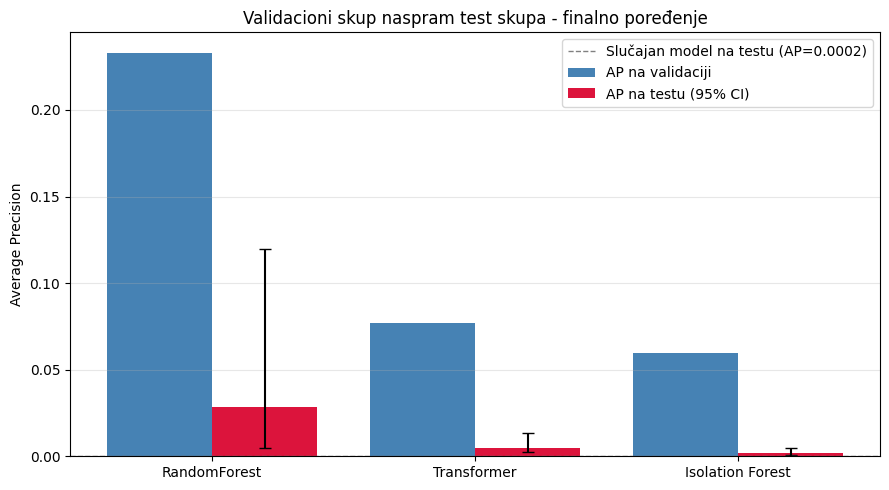

Grafik sačuvan: results/faza7_validacija_vs_test.png


In [ ]:
# --- 9. Vizuelno poređenje: AP na validacionom skupu naspram AP na test skupu ---
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(rezultati_finalni))
ax.bar(
    x - 0.2,
    [konfig_4["ap_validacija"], konfig_5["ap_validacija"], konfig_6["ap_validacija"]],
    0.4,
    label="AP na validaciji",
    color="steelblue",
)
ax.bar(
    x + 0.2,
    rezultati_finalni["AP test"],
    0.4,
    yerr=[
        rezultati_finalni["AP test"] - rezultati_finalni["AP CI donja"],
        rezultati_finalni["AP CI gornja"] - rezultati_finalni["AP test"],
    ],
    label="AP na testu (95% CI)",
    color="crimson",
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(rezultati_finalni["Model"])
ax.axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Slučajan model na testu (AP={y_test.mean():.4f})",
)
ax.set_ylabel("Average Precision")
ax.set_title("Validacioni skup naspram test skupa - finalno poređenje")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(RESULTS / "faza7_validacija_vs_test.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza7_validacija_vs_test.png")